<a href="https://colab.research.google.com/github/amrofadl/fyp/blob/main/fyp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

train_file_path = '/content/drive/MyDrive/ColabNotebooks/KDDTrain+.txt'
test_file_path = '/content/drive/MyDrive/ColabNotebooks/KDDTest+.txt'

col_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'label',
    'difficulty'
]

try:
    df_train = pd.read_csv(train_file_path, header=None, names=col_names)
    df_test = pd.read_csv(test_file_path, header=None, names=col_names)
except FileNotFoundError:
    print(f"Ensure '{train_file_path}' and '{test_file_path}' are correctly placed and paths are right.")
    exit()

In [ ]:
# Initial exploration
print("Training Data Info:")
df_train.info()
print("\nFirst 5 rows of Training Data:")
print(df_train.head())

print("\nTest Data Info:")
df_test.info()
print("\nFirst 5 rows of Test Data:")
print(df_test.head())

# Check unique values in the 'label' column (attack types)
print("\nUnique labels in training data:", df_train['label'].unique())
print("Label distribution in training data:")
print(df_train['label'].value_counts())

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 no

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import pandas as pd

# --- Preprocessing (Revised Step 4) ---

# Make sure df_train and df_test are loaded as per Step 3 in the previous guide
# Example:
# col_names = ["duration", ..., "label", "difficulty"]
# df_train = pd.read_csv(train_file_path, header=None, names=col_names)
# df_test = pd.read_csv(test_file_path, header=None, names=col_names)


# 1. Drop the 'difficulty' column (this operation returns a new DataFrame)
if 'difficulty' in df_train.columns:
    df_train = df_train.drop('difficulty', axis=1)
if 'difficulty' in df_test.columns:
    df_test = df_test.drop('difficulty', axis=1)

# Separate labels before extensive feature transformations
y_train_labels = df_train['label'].copy()
y_test_labels = df_test['label'].copy()

X_train_intermediate = df_train.drop('label', axis=1)
X_test_intermediate = df_test.drop('label', axis=1)

# 2. Identify categorical and numerical features from the original feature set
categorical_cols = ['protocol_type', 'service', 'flag']
# Ensure these cols actually exist in X_train_intermediate and X_test_intermediate
categorical_cols = [col for col in categorical_cols if col in X_train_intermediate.columns]

# 3. One-Hot Encode categorical features
# Using pandas.get_dummies. dummy_na=False means NaNs are not made into a separate category.
X_train_encoded = pd.get_dummies(X_train_intermediate, columns=categorical_cols, dummy_na=False)
X_test_encoded = pd.get_dummies(X_test_intermediate, columns=categorical_cols, dummy_na=False)

# 4. Align columns after one-hot encoding
# This is a more robust way to ensure both DataFrames have the same columns.
# Get all unique columns from both encoded DataFrames
all_train_cols = set(X_train_encoded.columns)
all_test_cols = set(X_test_encoded.columns)
combined_cols = list(all_train_cols.union(all_test_cols))

# Reindex both DataFrames to have all combined columns, fill missing ones with 0
# .reindex() returns a new DataFrame, avoiding SettingWithCopyWarning.
X_train_aligned = X_train_encoded.reindex(columns=combined_cols, fill_value=0)
X_test_aligned = X_test_encoded.reindex(columns=combined_cols, fill_value=0)

# Ensure the column order is the same (reindex might not preserve the exact order of the `combined_cols` list initially)
X_train_aligned = X_train_aligned[combined_cols]
X_test_aligned = X_test_aligned[combined_cols]

# At this point, X_train_aligned and X_test_aligned have the same features in the same order.

# 5. Encode the 'label' column (target variable)
# For binary classification: 'normal' vs 'attack'
y_train = y_train_labels.apply(lambda x: 0 if x == 'normal' else 1)
y_test = y_test_labels.apply(lambda x: 0 if x == 'normal' else 1)

# 6. Scale Numerical Features
# All columns in X_train_aligned and X_test_aligned are now numerical (either originally or from one-hot encoding)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_aligned)
X_test_scaled = scaler.transform(X_test_aligned) # Use transform only, no fit on test data!

# Convert scaled arrays back to DataFrames (optional, but good for inspection)
X_train_processed = pd.DataFrame(X_train_scaled, columns=X_train_aligned.columns)
X_test_processed = pd.DataFrame(X_test_scaled, columns=X_test_aligned.columns)

print("\nProcessed Training Data Head:")
print(X_train_processed.head())
print("\nTraining Labels Head:")
print(y_train.head())
print("\nProcessed Test Data Head:")
print(X_test_processed.head())
print("\nTest Labels Head:")
print(y_test.head())

print(f"\nShape of X_train_processed: {X_train_processed.shape}")
print(f"Shape of X_test_processed: {X_test_processed.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Processed Training Data Head:
   service_other  service_finger  service_ssh   flag_SF  duration  src_bytes  \
0      -0.189322       -0.119274    -0.049748  0.825150 -0.110249  -0.007679   
1       5.281999       -0.119274    -0.049748  0.825150 -0.110249  -0.007737   
2      -0.189322       -0.119274    -0.049748 -1.211901 -0.110249  -0.007762   
3      -0.189322       -0.119274    -0.049748  0.825150 -0.110249  -0.007723   
4      -0.189322       -0.119274    -0.049748  0.825150 -0.110249  -0.007728   

   protocol_type_udp  is_guest_login  service_urh_i  service_http_2784  ...  \
0          -0.367555       -0.097531       -0.00891          -0.002817  ...   
1           2.720684       -0.097531       -0.00891          -0.002817  ...   
2          -0.367555       -0.097531       -0.00891          -0.002817  ...   
3          -0.367555       -0.097531       -0.00891          -0.002817  ...   
4          -0.367555       -0.097531       -0.00891          -0.002817  ...   

   service_po


Training Decision Tree model...
Training complete.

Making predictions on the test set...
Predictions complete.

--- Decision Tree Model Evaluation ---
Accuracy: 0.8037

Confusion Matrix:
[[9333  378]
 [4047 8786]]
True Negatives (TN): 9333
False Positives (FP): 378  <-- Keep an eye on this for 'false alarms'
False Negatives (FN): 4047  <-- Keep an eye on this for 'missed attacks'
True Positives (TP): 8786

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.70      0.96      0.81      9711
  Attack (1)       0.96      0.68      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544

False Positive Rate (FPR): 0.0389
False Negative Rate (FNR): 0.3154
ROC AUC Score: 0.8230


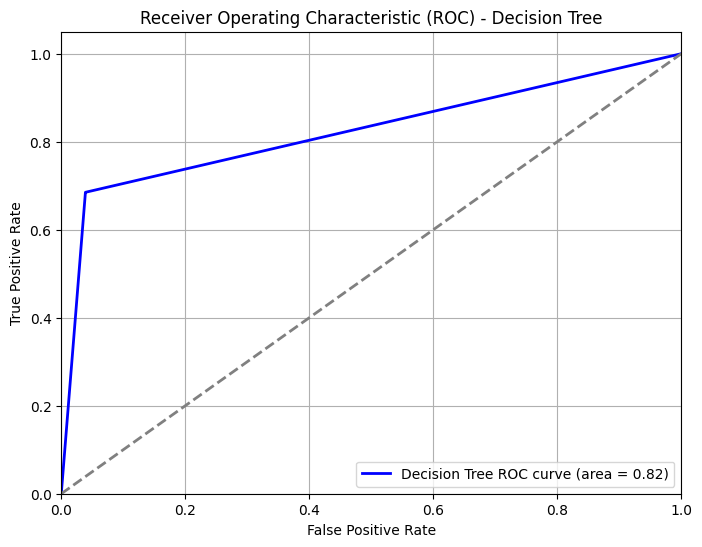


--------------------------------------


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt # For plotting ROC curve

# Ensure X_train_processed, y_train, X_test_processed, y_test are available
# from the previous preprocessing steps.

# Initialize the Decision Tree Classifier
# random_state is set for reproducibility - you'll get the same tree each time you run it with this state.
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the model using the processed training data
print("\nTraining Decision Tree model...")
dt_classifier.fit(X_train_processed, y_train)
print("Training complete.")

# Make predictions on the processed test set
print("\nMaking predictions on the test set...")
y_pred_dt = dt_classifier.predict(X_test_processed)
y_pred_proba_dt = dt_classifier.predict_proba(X_test_processed)[:, 1] # Probabilities for the positive class (for ROC AUC)
print("Predictions complete.")

# Evaluate the model
print("\n--- Decision Tree Model Evaluation ---")

# 1. Accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {accuracy_dt:.4f}")

# 2. Confusion Matrix
# TN | FP
# FN | TP
print("\nConfusion Matrix:")
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)
tn, fp, fn, tp = cm_dt.ravel()
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}  <-- Keep an eye on this for 'false alarms'")
print(f"False Negatives (FN): {fn}  <-- Keep an eye on this for 'missed attacks'")
print(f"True Positives (TP): {tp}")


# 3. Classification Report (Precision, Recall, F1-Score)
# target_names=['Normal (0)', 'Attack (1)'] assumes 0 is normal, 1 is attack.
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['Normal (0)', 'Attack (1)']))

# 4. False Positive Rate (FPR) and False Negative Rate (FNR)
fpr_dt = fp / (fp + tn) if (fp + tn) > 0 else 0
fnr_dt = fn / (fn + tp) if (fn + tp) > 0 else 0
print(f"False Positive Rate (FPR): {fpr_dt:.4f}")
print(f"False Negative Rate (FNR): {fnr_dt:.4f}")

# 5. ROC AUC Score
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
print(f"ROC AUC Score: {roc_auc_dt:.4f}")

# 6. Plot ROC Curve
fpr_roc, tpr_roc, thresholds_roc = roc_curve(y_test, y_pred_proba_dt)
plt.figure(figsize=(8, 6))
plt.plot(fpr_roc, tpr_roc, color='blue', lw=2, label=f'Decision Tree ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Decision Tree')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("\n--------------------------------------")


Training Support Vector Machine (SVM) model...
SVM Training complete. Time taken: 1419.39 seconds

Making predictions with SVM on the test set...
SVM Predictions complete.

--- Support Vector Machine (SVM) Model Evaluation ---
Accuracy: 0.7869

Confusion Matrix:
[[9007  704]
 [4099 8734]]
True Negatives (TN): 9007
False Positives (FP): 704 
False Negatives (FN): 4099 
True Positives (TP): 8734

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.69      0.93      0.79      9711
  Attack (1)       0.93      0.68      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.81      0.80      0.79     22544
weighted avg       0.82      0.79      0.79     22544

False Positive Rate (FPR): 0.0725
False Negative Rate (FNR): 0.3194
ROC AUC Score: 0.9043


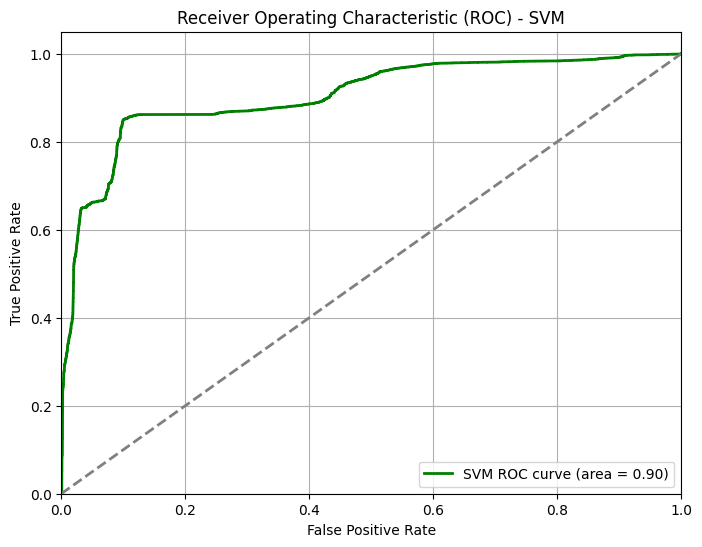


--------------------------------------


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import time # To time the training

# Ensure X_train_processed, y_train, X_test_processed, y_test are available
# from the previous preprocessing steps.

# Initialize the Support Vector Machine Classifier
# SVM can be sensitive to hyperparameters. These are some common starting points.
# 'kernel='rbf'' is a common default. 'C' is the regularization parameter.
# 'probability=True' is needed for predict_proba, but can make training slower.
svm_classifier = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)

# Train the model
print("\nTraining Support Vector Machine (SVM) model...")
start_time_svm = time.time()
svm_classifier.fit(X_train_processed, y_train)
end_time_svm = time.time()
print(f"SVM Training complete. Time taken: {end_time_svm - start_time_svm:.2f} seconds")

# Make predictions on the processed test set
print("\nMaking predictions with SVM on the test set...")
y_pred_svm = svm_classifier.predict(X_test_processed)
y_pred_proba_svm = svm_classifier.predict_proba(X_test_processed)[:, 1] # Probabilities for ROC AUC
print("SVM Predictions complete.")

# Evaluate the SVM model
print("\n--- Support Vector Machine (SVM) Model Evaluation ---")

# 1. Accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy: {accuracy_svm:.4f}")

# 2. Confusion Matrix
print("\nConfusion Matrix:")
cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)
tn_svm, fp_svm, fn_svm, tp_svm = cm_svm.ravel()
print(f"True Negatives (TN): {tn_svm}")
print(f"False Positives (FP): {fp_svm} ")
print(f"False Negatives (FN): {fn_svm} ")
print(f"True Positives (TP): {tp_svm}")

# 3. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Normal (0)', 'Attack (1)']))

# 4. False Positive Rate (FPR) and False Negative Rate (FNR)
fpr_svm = fp_svm / (fp_svm + tn_svm) if (fp_svm + tn_svm) > 0 else 0
fnr_svm = fn_svm / (fn_svm + tp_svm) if (fn_svm + tp_svm) > 0 else 0
print(f"False Positive Rate (FPR): {fpr_svm:.4f}")
print(f"False Negative Rate (FNR): {fnr_svm:.4f}")

# 5. ROC AUC Score
roc_auc_svm = roc_auc_score(y_test, y_pred_proba_svm)
print(f"ROC AUC Score: {roc_auc_svm:.4f}")

# 6. Plot ROC Curve for SVM
fpr_roc_svm, tpr_roc_svm, thresholds_roc_svm = roc_curve(y_test, y_pred_proba_svm)
plt.figure(figsize=(8, 6))
plt.plot(fpr_roc_svm, tpr_roc_svm, color='green', lw=2, label=f'SVM ROC curve (area = {roc_auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - SVM')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("\n--------------------------------------")


Defining Neural Network (MLP) model...
Compiling Neural Network model...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,113 (102.00 KB)

 Trainable params: 26,113 (102.00 KB)

 Non-trainable params: 0 (0.00 B)


Training Neural Network model...
(This might take some time depending on epochs, batch_size, and Colab resources)
Epoch 1/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9497 - loss: 0.1309 - val_accuracy: 0.9916 - val_loss: 0.0264
Epoch 2/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9888 - loss: 0.0321 - val_accuracy: 0.9910 - val_loss: 0.0219
Epoch 3/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9909 - loss: 0.0243 - val_accuracy: 0.9927 - val_loss: 0.0208
Epoch 4/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9920 - loss: 0.0223 - val_accuracy: 0.9940 - val_loss: 0.0195
Epoch 5/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9929 - loss: 0.0204 - val_accuracy: 0.9939 - val_loss: 0.0178
Epoch 6/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9934 - loss: 0.0188 - val_accuracy: 0.9945 - val_loss: 0.0174
Epoch 7/20
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9935 - loss: 0.0188 - val_accuracy: 

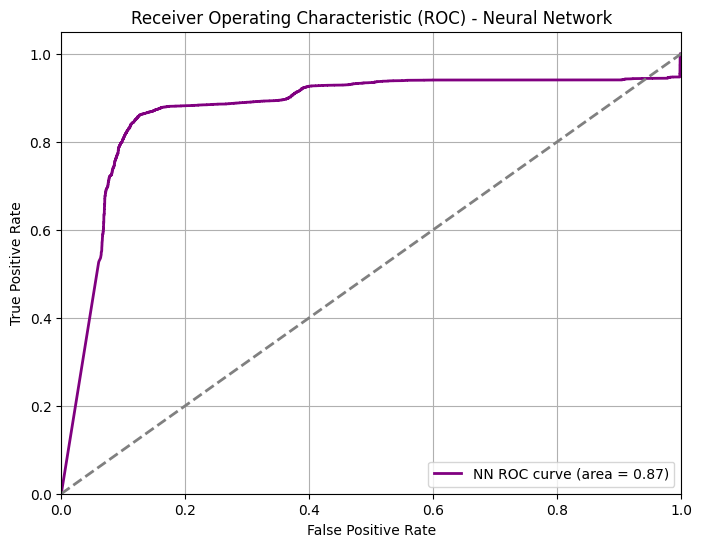

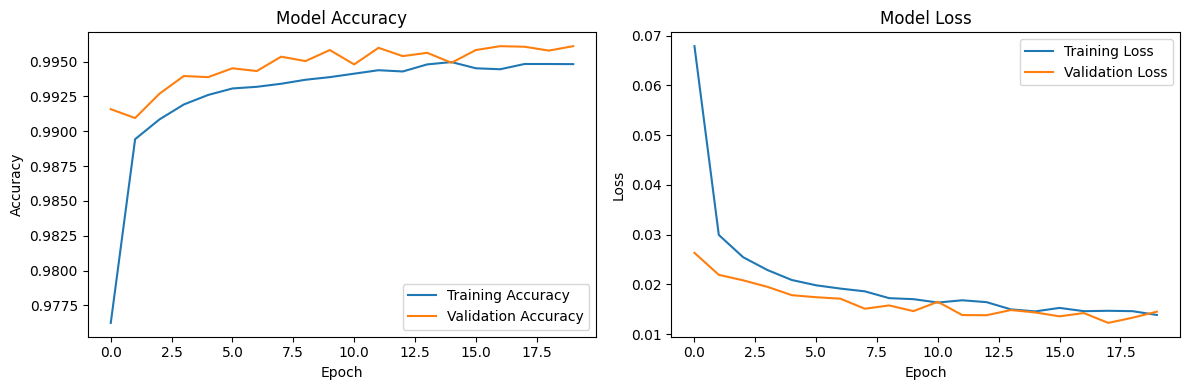


--------------------------------------


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np # For argmax if needed, and handling predictions
import time

# Ensure X_train_processed, y_train, X_test_processed, y_test are available
# from your successful preprocessing steps for NSL-KDD.
# X_train_processed and X_test_processed should be pandas DataFrames or NumPy arrays.
# y_train and y_test should be pandas Series or NumPy arrays with binary labels (0 or 1).

# Define the Neural Network Model (MLP)
print("\nDefining Neural Network (MLP) model...")
nn_model = Sequential([
    # Input layer: needs to know the number of input features
    # X_train_processed.shape[1] gives the number of features
    Dense(128, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.3), # Dropout layer to reduce overfitting
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    # Output layer: 1 neuron with sigmoid activation for binary classification
    Dense(1, activation='sigmoid')
])

# Compile the model
# Adam is a common and effective optimizer.
# Binary crossentropy is suitable for binary classification problems.
print("Compiling Neural Network model...")
nn_model.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# Print model summary
nn_model.summary()

# Train the model
# epochs: number of times the model will cycle through the entire training dataset.
# batch_size: number of samples processed before the model is updated.
# validation_split: fraction of the training data to be used as validation data.
#                   The model will not train on this data. Instead, it will evaluate
#                   the loss and any model metrics on this data at the end of each epoch.
print("\nTraining Neural Network model...")
print("(This might take some time depending on epochs, batch_size, and Colab resources)")
start_time_nn = time.time()
history = nn_model.fit(X_train_processed, y_train,
                       epochs=20,  # You can start with 10-20 and increase if needed
                       batch_size=64, # Common batch sizes are 32, 64, 128
                       validation_split=0.2, # Use 20% of training data for validation
                       verbose=1) # verbose=1 will show progress bar
end_time_nn = time.time()
print(f"Neural Network Training complete. Time taken: {end_time_nn - start_time_nn:.2f} seconds")

# Make predictions on the processed test set
print("\nMaking predictions with Neural Network on the test set...")
# .predict() returns probabilities for the sigmoid output layer
y_pred_proba_nn = nn_model.predict(X_test_processed).ravel() # .ravel() to make it a 1D array
# Convert probabilities to binary class labels (0 or 1) using a 0.5 threshold
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)
print("Neural Network Predictions complete.")


# Evaluate the Neural Network model
print("\n--- Neural Network (MLP) Model Evaluation ---")

# 1. Accuracy
accuracy_nn = accuracy_score(y_test, y_pred_nn)
print(f"Accuracy: {accuracy_nn:.4f}")

# 2. Confusion Matrix
print("\nConfusion Matrix:")
cm_nn = confusion_matrix(y_test, y_pred_nn)
print(cm_nn)
if cm_nn.size == 4: # Ensure it's a 2x2 matrix
    tn_nn, fp_nn, fn_nn, tp_nn = cm_nn.ravel()
    print(f"True Negatives (TN): {tn_nn}")
    print(f"False Positives (FP): {fp_nn}")
    print(f"False Negatives (FN): {fn_nn}")
    print(f"True Positives (TP): {tp_nn}")

    # 4. False Positive Rate (FPR) and False Negative Rate (FNR)
    fpr_nn = fp_nn / (fp_nn + tn_nn) if (fp_nn + tn_nn) > 0 else 0
    fnr_nn = fn_nn / (fn_nn + tp_nn) if (fn_nn + tp_nn) > 0 else 0
    print(f"False Positive Rate (FPR): {fpr_nn:.4f}")
    print(f"False Negative Rate (FNR): {fnr_nn:.4f}")
else:
    print("Confusion matrix is not 2x2. Cannot unpack TN, FP, FN, TP directly for binary metrics.")

# 3. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, target_names=['Normal (0)', 'Attack (1)']))

# 5. ROC AUC Score
if len(set(y_test)) == 2 : # Check if y_test is binary
    roc_auc_nn = roc_auc_score(y_test, y_pred_proba_nn)
    print(f"ROC AUC Score: {roc_auc_nn:.4f}")

    # 6. Plot ROC Curve
    fpr_roc_nn, tpr_roc_nn, thresholds_roc_nn = roc_curve(y_test, y_pred_proba_nn)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_roc_nn, tpr_roc_nn, color='purple', lw=2, label=f'NN ROC curve (area = {roc_auc_nn:.2f})')
    plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) - Neural Network')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # Optional: Plot training & validation accuracy and loss
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("ROC AUC score and curve are typically for binary classification tasks or require multi-class adaptation.")

print("\n--------------------------------------")


Keras nn_model wrapped successfully for VotingClassifier.
Initializing Voting Classifier (Hybrid Model)...
Fitting/Setting up Voting Classifier...
Voting Classifier setup complete. Time taken: 1410.63 seconds

Making predictions with Voting Classifier...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Voting Classifier Predictions complete.

--- Voting Classifier (Hybrid) Evaluation ---
Accuracy: 0.7893

Confusion Matrix:
[[9015  696]
 [4055 8778]]
True Negatives (TN): 9015
False Positives (FP): 696
False Negatives (FN): 4055
True Positives (TP): 8778
False Positive Rate (FPR): 0.0717
False Negative Rate (FNR): 0.3160

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.69      0.93      0.79      9711
  Attack (1)       0.93      0.68      0.79     12833

    accuracy                           0.79     22544
   macro avg       0.81      0.81      0.79     22544
weighted avg       0.82      0.79      0.79     22544

ROC AUC Score: 0.9230


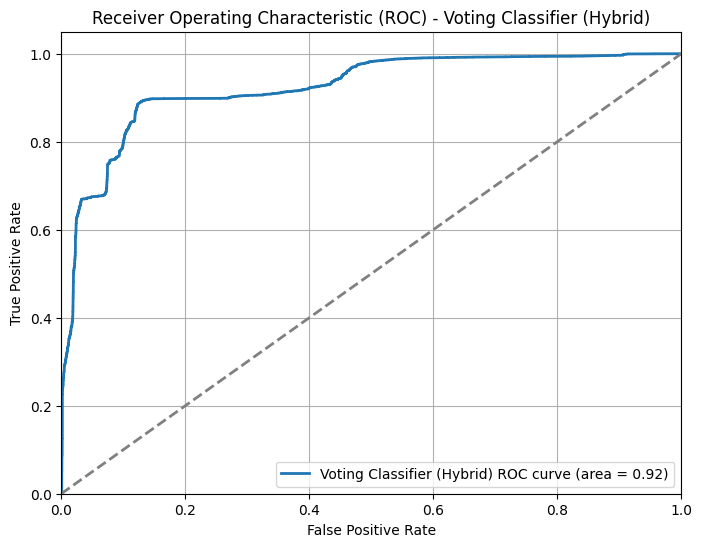

--------------------------------------

--- End of Hybrid Model Script ---


In [ ]:
# ---------------------------------------------------------------------------
# IMPORTS (Ensure these are run if not already in your session for the hybrid part)
# ---------------------------------------------------------------------------
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np # For array manipulations and KerasModelWrapper
import pandas as pd # For KerasModelWrapper if X is DataFrame
import time

# ---------------------------------------------------------------------------
# EVALUATION FUNCTION (Include this if it's not already defined in your session from a previous run)
# ---------------------------------------------------------------------------
def evaluate_model(y_true, y_pred_labels, y_pred_proba, model_name="Model"):
    print(f"\n--- {model_name} Evaluation ---")
    accuracy = accuracy_score(y_true, y_pred_labels)
    print(f"Accuracy: {accuracy:.4f}")

    cm = confusion_matrix(y_true, y_pred_labels)
    print("\nConfusion Matrix:")
    print(cm)
    # Initialize metrics to avoid NameError if cm.size != 4
    tn, fp, fn, tp = 0, 0, 0, 0
    fpr, fnr, roc_auc = -1.0, -1.0, -1.0 # Default to -1 if not calculable

    if cm.size == 4: # Binary classification
        tn, fp, fn, tp = cm.ravel()
        print(f"True Negatives (TN): {tn}")
        print(f"False Positives (FP): {fp}")
        print(f"False Negatives (FN): {fn}")
        print(f"True Positives (TP): {tp}")
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        print(f"False Positive Rate (FPR): {fpr:.4f}")
        print(f"False Negative Rate (FNR): {fnr:.4f}")
    else:
        print("Confusion matrix not 2x2, binary metrics (FPR/FNR) not directly unpacked.")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred_labels, target_names=['Normal (0)', 'Attack (1)'], zero_division=0))

    if y_pred_proba is not None and len(set(y_true)) == 2 :
        try:
            roc_auc = roc_auc_score(y_true, y_pred_proba)
            print(f"ROC AUC Score: {roc_auc:.4f}")
            fpr_roc, tpr_roc, _ = roc_curve(y_true, y_pred_proba)
            plt.figure(figsize=(8, 6))
            plt.plot(fpr_roc, tpr_roc, lw=2, label=f'{model_name} ROC curve (area = {roc_auc:.2f})')
            plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
            plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
            plt.title(f'Receiver Operating Characteristic (ROC) - {model_name}'); plt.legend(loc="lower right"); plt.grid(True); plt.show()
        except ValueError as e_roc:
            print(f"Could not calculate ROC AUC or plot ROC curve: {e_roc}")
            roc_auc = -1.0 # Indicate error or not applicable
    elif y_pred_proba is None:
        print("Probabilities not provided, skipping ROC AUC and curve.")
        roc_auc = -1.0
    elif len(set(y_true)) != 2:
         print("ROC AUC score and curve are typically for binary classification tasks.")
         roc_auc = -1.0
    print("--------------------------------------")
    # If you are collecting all results in a list:
    # return {"name": model_name, "accuracy": accuracy, "fpr": fpr, "fnr": fnr, "roc_auc": roc_auc}

# ---------------------------------------------------------------------------
# CORRECTED KerasModelWrapper CLASS (with dummy fit method)
# ---------------------------------------------------------------------------
class KerasModelWrapper:
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])
        self._estimator_type = "classifier" # Crucial for Scikit-learn compatibility

    def fit(self, X, y=None, **kwargs):
        # This wrapper is for a pre-trained Keras model,
        # so this 'fit' method does nothing other than satisfy the API.
        # It must return self.
        return self

    def predict(self, X):
        if isinstance(X, pd.DataFrame): X_np = X.values
        else: X_np = X
        return (self.model.predict(X_np) > 0.5).astype(int).ravel()

    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame): X_np = X.values
        else: X_np = X
        proba_pos = self.model.predict(X_np).ravel()
        return np.vstack((1 - proba_pos, proba_pos)).T

    def get_params(self, deep=True):
        return {"model": self.model}

    def set_params(self, **params):
        for param, value in params.items():
            setattr(self, param, value)
        return self

# ---------------------------------------------------------------------------
# HYBRID MODEL (VOTING CLASSIFIER) IMPLEMENTATION
# ---------------------------------------------------------------------------

# Ensure your base classifiers (dt_classifier, svm_classifier, nn_model)
# and data (X_train_processed, y_train, X_test_processed, y_test) are
# ALREADY DEFINED AND TRAINED in your current Colab session.

# Check if all necessary variables are defined
if ('dt_classifier' in globals() and dt_classifier is not None and
    'svm_classifier' in globals() and svm_classifier is not None and
    'nn_model' in globals() and nn_model is not None and
    'X_train_processed' in globals() and 'y_train' in globals() and
    'X_test_processed' in globals() and 'y_test' in globals()):

    # Wrap your existing trained nn_model
    nn_model_wrapped = KerasModelWrapper(nn_model)
    print("\nKeras nn_model wrapped successfully for VotingClassifier.")

    print("Initializing Voting Classifier (Hybrid Model)...")
    voting_clf = VotingClassifier(
        estimators=[
            ('dt', dt_classifier),
            ('svm', svm_classifier),
            ('nn', nn_model_wrapped)
        ],
        voting='soft'  # 'soft' uses predicted probabilities
    )

    print("Fitting/Setting up Voting Classifier...")
    start_time_vc = time.time()
    # The fit method of KerasModelWrapper does nothing, so base models are not retrained.
    # This call is primarily for VotingClassifier to validate and store the estimators.
    voting_clf.fit(X_train_processed.values if isinstance(X_train_processed, pd.DataFrame) else X_train_processed,
                   y_train.values if isinstance(y_train, pd.Series) else y_train)
    end_time_vc = time.time()
    print(f"Voting Classifier setup complete. Time taken: {end_time_vc - start_time_vc:.2f} seconds")

    print("\nMaking predictions with Voting Classifier...")
    y_pred_vc = voting_clf.predict(X_test_processed)
    y_pred_proba_vc = None # Initialize
    if hasattr(voting_clf, "predict_proba"): # Check if soft voting enabled this
        y_pred_proba_vc = voting_clf.predict_proba(X_test_processed)[:, 1]
    else:
        print("predict_proba not available for the VotingClassifier (might be hard voting or an issue).")
    print("Voting Classifier Predictions complete.")

    # Evaluate the Voting Classifier model (using the helper function)
    # If you have an 'all_results' list from the full script, you can append to it:
    # results_vc = evaluate_model(y_test, y_pred_vc, y_pred_proba_vc, "Voting Classifier (Hybrid)")
    # if 'all_results' in globals() and isinstance(all_results, list):
    #    all_results.append(results_vc)
    # else: # If running standalone, just print
    evaluate_model(y_test, y_pred_vc, y_pred_proba_vc, "Voting Classifier (Hybrid)")

else:
    print("\nError: One or more base models (dt_classifier, svm_classifier, nn_model) or "
          "processed data (X_train_processed, y_train, X_test_processed, y_test) "
          "are not available in the current session. Please ensure they are defined and trained/loaded.")

print("\n--- End of Hybrid Model Script ---")


Starting Sparse Autoencoder implementation for feature engineering...
Original feature dimension: 122
Target encoding dimension: 64

Sparse Autoencoder Architecture:


Model: "SparseAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ AE_Input (InputLayer)           │ (None, 122)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Encoder_Output (Dense)       │ (None, 64)             │         7,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AE_Decoder_Output (Dense)       │ (None, 122)            │         7,930 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,802 (61.73 KB)

 Trainable params: 15,802 (61.73 KB)

 Non-trainable params: 0 (0.00 B)


Training Sparse Autoencoder...
Epoch 1/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.4123 - val_loss: 0.8702
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8483 - val_loss: 0.7411
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.7382 - val_loss: 0.6563
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.6391 - val_loss: 0.6002
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5862 - val_loss: 0.5654
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.5750 - val_loss: 0.5245
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5279 - val_loss: 0.5045
Epoch 8/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4741 - val_loss: 0.4963
Epoch 9/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4481 - val_loss: 0.4712
Epoch 10/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.4503 - val_loss: 0.4558
Epoch 11/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4664 - val_loss: 0.4513
Epoch 12/50
394/394 

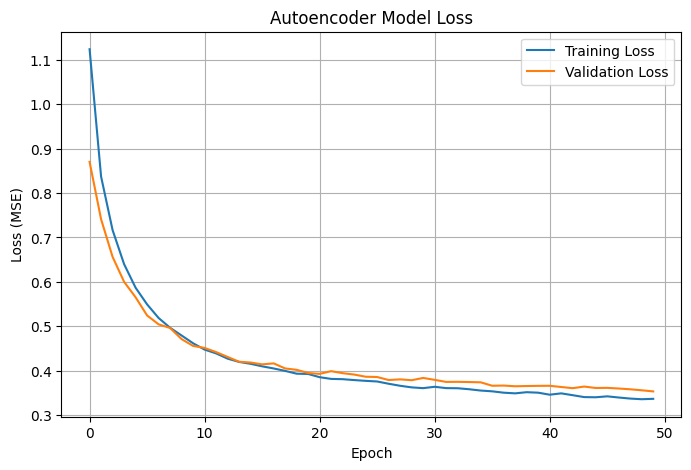


Extracting features using the trained encoder...
3937/3937 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
New features extracted successfully.
Shape of new training features: (125973, 64)
Shape of new testing features: (22544, 64)

First 5 rows of new training features (from Autoencoder):
   AE_Feat_1  AE_Feat_2  AE_Feat_3  AE_Feat_4  AE_Feat_5  AE_Feat_6  \
0        0.0        0.0        0.0        0.0        0.0        0.0   
1        0.0        0.0        0.0        0.0        0.0        0.0   
2        0.0        0.0        0.0        0.0        0.0        0.0   
3        0.0        0.0        0.0        0.0        0.0        0.0   
4        0.0        0.0        0.0        0.0        0.0        0.0   

   AE_Feat_7  AE_Feat_8  AE_Feat_9  AE_Feat_10  ...  AE_Feat_55  AE_Feat_56  \
0   0.110236        0.0        0.0         0.0  ...         0.0         0.0   
1   0.040618        0.0        0.0         0.0  ...         0.0         0.0   
2   0.797187      

In [ ]:
# ---------------------------------------------------------------------------
# IMPORTS (Ensure these are run, especially TensorFlow/Keras parts)
# ---------------------------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, ActivityRegularization
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Ensure X_train_processed and X_test_processed are available from your
# previous preprocessing steps. They should be pandas DataFrames or NumPy arrays.
# These are the features that will be fed into the autoencoder.

# ---------------------------------------------------------------------------
# SPARSE AUTOENCODER FOR FEATURE LEARNING
# ---------------------------------------------------------------------------

if ('X_train_processed' not in globals() or
    'X_test_processed' not in globals()):
    print("Error: X_train_processed or X_test_processed not found. Please ensure preprocessing is complete.")
else:
    print("\nStarting Sparse Autoencoder implementation for feature engineering...")
    # --- 1. Define Autoencoder Architecture ---
    input_dim = X_train_processed.shape[1]

    # Encoding dimension: This is a hyperparameter. It should be smaller than input_dim.
    # Let's choose a value, e.g., 64 or 32. You might need to experiment.
    # If input_dim is already small after one-hot encoding (e.g., around 120-150 for NSL-KDD),
    # an encoding_dim of 64 or 32 could be reasonable.
    encoding_dim = 64 # Example, adjust as needed

    print(f"Original feature dimension: {input_dim}")
    print(f"Target encoding dimension: {encoding_dim}")

    # Input Layer
    input_layer = Input(shape=(input_dim,), name="AE_Input")

    # Encoder Layer
    # Using l1 activity regularization to encourage sparsity
    encoder_layer = Dense(encoding_dim, activation='relu',
                          activity_regularizer=tf.keras.regularizers.l1(10e-5), # L1 sparsity constraint
                          name="AE_Encoder_Output")(input_layer)

    # Decoder Layer
    # The decoder tries to reconstruct the original input from the encoding
    # The output layer should have the same number of neurons as the input_dim
    # Using 'linear' activation as X_train_processed is standardized (can be negative)
    decoder_layer = Dense(input_dim, activation='linear', name="AE_Decoder_Output")(encoder_layer) # Or 'relu' if inputs were always non-negative

    # Autoencoder Model (ties encoder and decoder)
    autoencoder = Model(inputs=input_layer, outputs=decoder_layer, name="SparseAutoencoder")

    # Encoder Model (for extracting features later)
    # This model will take the input and output the encoded representation
    encoder_model = Model(inputs=input_layer, outputs=encoder_layer, name="Encoder")

    # --- 2. Compile the Autoencoder Model ---
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
    print("\nSparse Autoencoder Architecture:")
    autoencoder.summary()

    # --- 3. Train the Autoencoder ---
    # The autoencoder is trained to reconstruct its own input,
    # so X_train_processed is used as both the input and the target.
    print("\nTraining Sparse Autoencoder...")
    start_time_ae = time.time()
    # Using X_train_processed.values if it's a DataFrame to ensure NumPy array input
    ae_history = autoencoder.fit(X_train_processed.values if isinstance(X_train_processed, pd.DataFrame) else X_train_processed,
                                 X_train_processed.values if isinstance(X_train_processed, pd.DataFrame) else X_train_processed,
                                 epochs=50,       # Adjust epochs as needed
                                 batch_size=256,    # Adjust batch size as needed
                                 shuffle=True,
                                 validation_split=0.2, # Use part of training data for validation
                                 verbose=1)
    end_time_ae = time.time()
    print(f"Sparse Autoencoder training complete. Time taken: {end_time_ae - start_time_ae:.2f} seconds")

    # Plot training & validation loss (optional but recommended)
    if ae_history is not None:
        plt.figure(figsize=(8, 5))
        plt.plot(ae_history.history['loss'], label='Training Loss')
        if 'val_loss' in ae_history.history:
            plt.plot(ae_history.history['val_loss'], label='Validation Loss')
        plt.title('Autoencoder Model Loss')
        plt.xlabel('Epoch'); plt.ylabel('Loss (MSE)'); plt.legend(); plt.grid(True); plt.show()

    # --- 4. Extract Learned Features using the Encoder ---
    print("\nExtracting features using the trained encoder...")
    X_train_ae_features_array = encoder_model.predict(X_train_processed.values if isinstance(X_train_processed, pd.DataFrame) else X_train_processed)
    X_test_ae_features_array = encoder_model.predict(X_test_processed.values if isinstance(X_test_processed, pd.DataFrame) else X_test_processed)

    # Convert to DataFrames (optional, but can be convenient)
    # Create meaningful column names for the new features
    ae_feature_columns = [f'AE_Feat_{i+1}' for i in range(encoding_dim)]
    X_train_ae_features = pd.DataFrame(X_train_ae_features_array, columns=ae_feature_columns)
    X_test_ae_features = pd.DataFrame(X_test_ae_features_array, columns=ae_feature_columns)

    print("New features extracted successfully.")
    print(f"Shape of new training features: {X_train_ae_features.shape}")
    print(f"Shape of new testing features: {X_test_ae_features.shape}")
    print("\nFirst 5 rows of new training features (from Autoencoder):")
    print(X_train_ae_features.head())

    print("\n--- End of Sparse Autoencoder Feature Engineering ---")


--- Re-training and Re-evaluating models on Autoencoder Features ---

--- Decision Tree (AE Features) ---
Training Decision Tree model with AE features...
Training complete. Time taken: 3.13 seconds

--- Decision Tree (AE Features) Evaluation ---
Accuracy: 0.8016

Confusion Matrix:
[[9435  276]
 [4196 8637]]
True Negatives (TN): 9435
False Positives (FP): 276
False Negatives (FN): 4196
True Positives (TP): 8637
False Positive Rate (FPR): 0.0284
False Negative Rate (FNR): 0.3270

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.69      0.97      0.81      9711
  Attack (1)       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544

ROC AUC Score: 0.7364


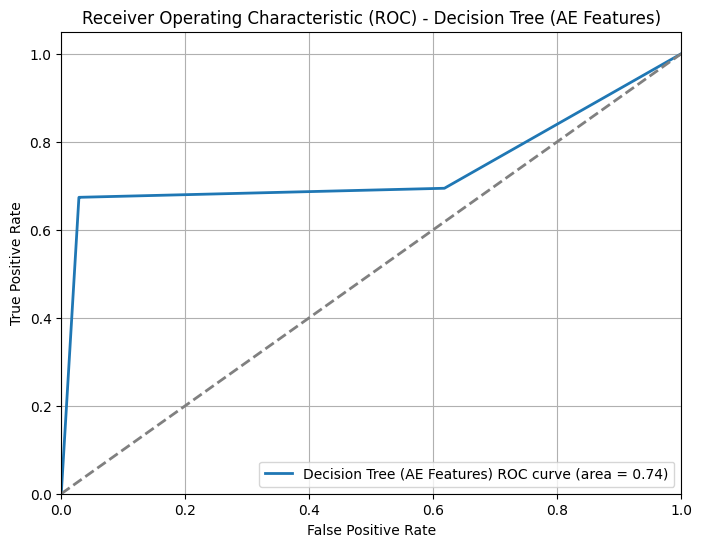

--------------------------------------

--- Support Vector Machine (SVM) (AE Features) ---
Training SVM model with AE features... (This might take a while)
Training complete. Time taken: 2832.89 seconds

--- SVM (AE Features) Evaluation ---
Accuracy: 0.7934

Confusion Matrix:
[[9434  277]
 [4380 8453]]
True Negatives (TN): 9434
False Positives (FP): 277
False Negatives (FN): 4380
True Positives (TP): 8453
False Positive Rate (FPR): 0.0285
False Negative Rate (FNR): 0.3413

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.68      0.97      0.80      9711
  Attack (1)       0.97      0.66      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.83      0.82      0.79     22544
weighted avg       0.85      0.79      0.79     22544

ROC AUC Score: 0.9331


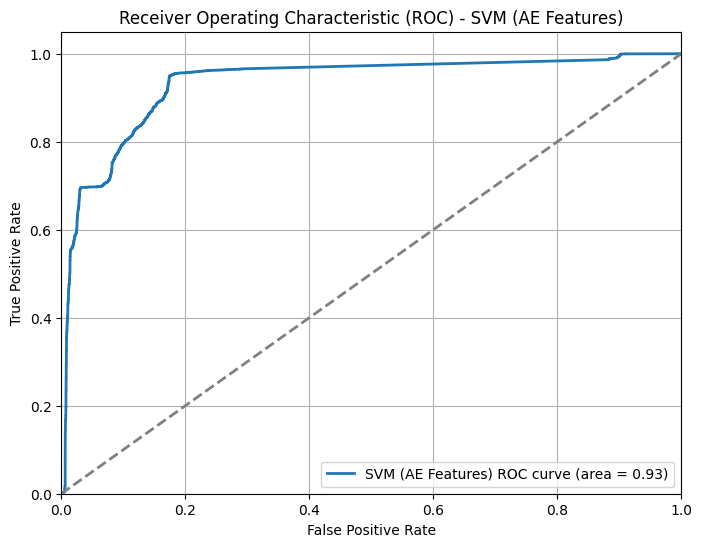

--------------------------------------

--- Neural Network (MLP) (AE Features) ---
NN (AE) Model Summary:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)


Training Neural Network (AE) model...
Training complete. Time taken: 132.18 seconds


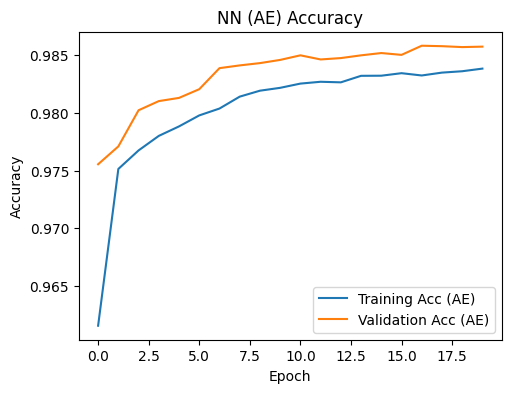

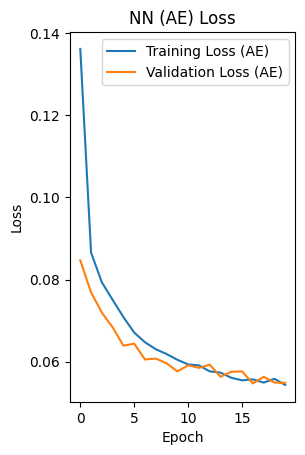

705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

--- Neural Network (MLP) (AE Features) Evaluation ---
Accuracy: 0.7864

Confusion Matrix:
[[9460  251]
 [4564 8269]]
True Negatives (TN): 9460
False Positives (FP): 251
False Negatives (FN): 4564
True Positives (TP): 8269
False Positive Rate (FPR): 0.0258
False Negative Rate (FNR): 0.3556

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.67      0.97      0.80      9711
  Attack (1)       0.97      0.64      0.77     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.78     22544

ROC AUC Score: 0.8081


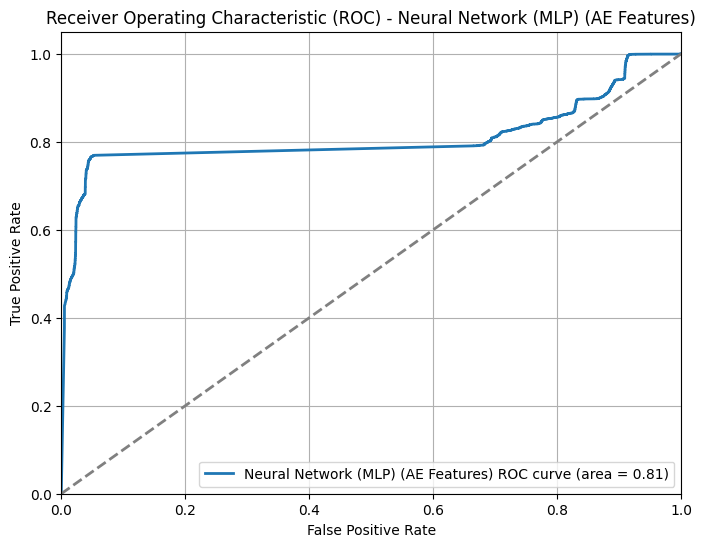

--------------------------------------

--- Voting Classifier (Hybrid Model) (AE Features) ---
Keras nn_model_ae wrapped successfully.
Fitting/Setting up Voting Classifier with AE models...
Voting Classifier (AE) setup complete. Time taken: 2981.50 seconds


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Voting Classifier (AE Features) Evaluation ---
Accuracy: 0.7963

Confusion Matrix:
[[9453  258]
 [4334 8499]]
True Negatives (TN): 9453
False Positives (FP): 258
False Negatives (FN): 4334
True Positives (TP): 8499
False Positive Rate (FPR): 0.0266
False Negative Rate (FNR): 0.3377

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.69      0.97      0.80      9711
  Attack (1)       0.97      0.66      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.79     22544

ROC AUC Score: 0.9086


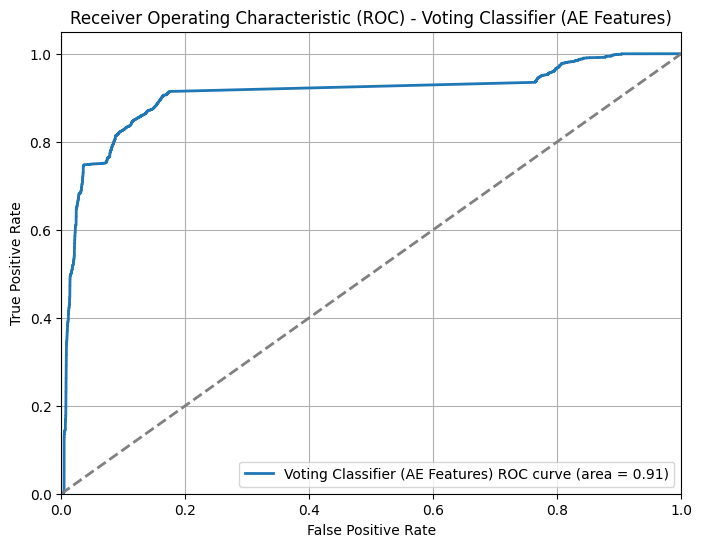

--------------------------------------


--- End of Re-training on Autoencoder Features ---


In [ ]:
import time
# Assuming necessary model classes like DecisionTreeClassifier, SVC, Sequential, Dense, Dropout, VotingClassifier
# and the evaluate_model function and KerasModelWrapper class are already defined and imported.
# Also assuming X_train_ae_features, X_test_ae_features, y_train, y_test are available.

# Check if AE features are available
if ('X_train_ae_features' not in globals() or 'X_test_ae_features' not in globals() or
    'y_train' not in globals() or 'y_test' not in globals()):
    print("ERROR: Autoencoder features (X_train_ae_features, X_test_ae_features) or labels (y_train, y_test) not found.")
    print("Please ensure the Sparse Autoencoder script has been run successfully to generate these.")
else:
    print("\n--- Re-training and Re-evaluating models on Autoencoder Features ---")

    # If you are collecting results in a list for a new comparison table:
    # all_results_ae = [] # Initialize a new list for AE model results

    # --- 1. Decision Tree with AE Features ---
    print("\n--- Decision Tree (AE Features) ---")
    dt_classifier_ae = DecisionTreeClassifier(random_state=42)
    print("Training Decision Tree model with AE features...")
    start_time_dt_ae = time.time()
    dt_classifier_ae.fit(X_train_ae_features, y_train)
    end_time_dt_ae = time.time()
    print(f"Training complete. Time taken: {end_time_dt_ae - start_time_dt_ae:.2f} seconds")
    y_pred_dt_ae = dt_classifier_ae.predict(X_test_ae_features)
    y_pred_proba_dt_ae = dt_classifier_ae.predict_proba(X_test_ae_features)[:, 1]
    evaluate_model(y_test, y_pred_dt_ae, y_pred_proba_dt_ae, "Decision Tree (AE Features)")
    # if 'all_results_ae' in globals(): all_results_ae.append(evaluate_model(...)) # if collecting

    # --- 2. SVM with AE Features ---
    print("\n--- Support Vector Machine (SVM) (AE Features) ---")
    svm_classifier_ae = SVC(kernel='rbf', C=1.0, random_state=42, probability=True)
    print("Training SVM model with AE features... (This might take a while)")
    start_time_svm_ae = time.time()
    svm_classifier_ae.fit(X_train_ae_features, y_train)
    end_time_svm_ae = time.time()
    print(f"Training complete. Time taken: {end_time_svm_ae - start_time_svm_ae:.2f} seconds")
    y_pred_svm_ae = svm_classifier_ae.predict(X_test_ae_features)
    y_pred_proba_svm_ae = svm_classifier_ae.predict_proba(X_test_ae_features)[:, 1]
    evaluate_model(y_test, y_pred_svm_ae, y_pred_proba_svm_ae, "SVM (AE Features)")
    # if 'all_results_ae' in globals(): all_results_ae.append(evaluate_model(...))

    # --- 3. Neural Network (MLP) with AE Features ---
    if 'tf' not in globals(): # Basic check if TensorFlow was intended to be loaded
        print("\nSkipping Neural Network (AE Features) as TensorFlow (tf) might not be loaded.")
    else:
        print("\n--- Neural Network (MLP) (AE Features) ---")
        ae_input_dim = X_train_ae_features.shape[1] # Should be your encoding_dim (e.g., 64)
        nn_model_ae = Sequential([
            Dense(128, activation='relu', input_shape=(ae_input_dim,)),
            Dropout(0.3),
            Dense(64, activation='relu'),
            Dropout(0.3),
            Dense(32, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        nn_model_ae.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        print("NN (AE) Model Summary:")
        nn_model_ae.summary()
        print("\nTraining Neural Network (AE) model...")
        start_time_nn_ae = time.time()
        history_ae = nn_model_ae.fit(X_train_ae_features, y_train,
                                   epochs=20, batch_size=64, validation_split=0.2, verbose=0)
        end_time_nn_ae = time.time()
        print(f"Training complete. Time taken: {end_time_nn_ae - start_time_nn_ae:.2f} seconds")

        # Optional: Plot training history for NN_AE
        if history_ae is not None:
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 2, 1); plt.plot(history_ae.history['accuracy'], label='Training Acc (AE)')
            if 'val_accuracy' in history_ae.history: plt.plot(history_ae.history['val_accuracy'], label='Validation Acc (AE)')
            plt.title('NN (AE) Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()
            plt.subplot(1, 2, 2); plt.plot(history_ae.history['loss'], label='Training Loss (AE)')
            if 'val_loss' in history_ae.history: plt.plot(history_ae.history['val_loss'], label='Validation Loss (AE)')
            plt.title('NN (AE) Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

        y_pred_proba_nn_ae = nn_model_ae.predict(X_test_ae_features).ravel()
        y_pred_nn_ae = (y_pred_proba_nn_ae > 0.5).astype(int)
        evaluate_model(y_test, y_pred_nn_ae, y_pred_proba_nn_ae, "Neural Network (MLP) (AE Features)")
        # if 'all_results_ae' in globals(): all_results_ae.append(evaluate_model(...))

    # --- 4. Hybrid Model (Voting Classifier) with AE Features ---
    # Ensure KerasModelWrapper class is defined in your session
    if ('dt_classifier_ae' in globals() and 'svm_classifier_ae' in globals() and
        'nn_model_ae' in globals() and 'KerasModelWrapper' in globals()):

        print("\n--- Voting Classifier (Hybrid Model) (AE Features) ---")
        nn_model_ae_wrapped = KerasModelWrapper(nn_model_ae) # Wrap the NN trained on AE features
        print("Keras nn_model_ae wrapped successfully.")

        voting_clf_ae = VotingClassifier(
            estimators=[
                ('dt_ae', dt_classifier_ae),
                ('svm_ae', svm_classifier_ae),
                ('nn_ae', nn_model_ae_wrapped)
            ],
            voting='soft'
        )
        print("Fitting/Setting up Voting Classifier with AE models...")
        start_time_vc_ae = time.time()
        # Use .values for numpy arrays if needed by Keras wrapper internally, though fit here is on VotingClassifier
        X_train_input_vc_ae = X_train_ae_features.values if isinstance(X_train_ae_features, pd.DataFrame) else X_train_ae_features
        y_train_input_vc_ae = y_train.values if isinstance(y_train, pd.Series) else y_train
        voting_clf_ae.fit(X_train_input_vc_ae, y_train_input_vc_ae)
        end_time_vc_ae = time.time()
        print(f"Voting Classifier (AE) setup complete. Time taken: {end_time_vc_ae - start_time_vc_ae:.2f} seconds")

        y_pred_vc_ae = voting_clf_ae.predict(X_test_ae_features)
        y_pred_proba_vc_ae = None
        if hasattr(voting_clf_ae, "predict_proba"):
            y_pred_proba_vc_ae = voting_clf_ae.predict_proba(X_test_ae_features)[:, 1]

        evaluate_model(y_test, y_pred_vc_ae, y_pred_proba_vc_ae, "Voting Classifier (AE Features)")
        # if 'all_results_ae' in globals(): all_results_ae.append(evaluate_model(...))
    else:
        print("\nSkipping Voting Classifier (AE Features) as one or more base AE models or KerasModelWrapper were not available.")

    print("\n\n--- End of Re-training on Autoencoder Features ---")